In [2]:
import numpy as np
from brian2 import *
import pandas as pd

In [3]:
N = 120 # Number of neurons
psi_samples = np.linspace(0, 2*np.pi, 10*N, endpoint=False)
w_samples = np.linspace(2*np.pi/N, 2*(N-1)*np.pi/N, 10*N, endpoint=False)

psi_grid, w_grid = np.meshgrid(psi_samples, w_samples)

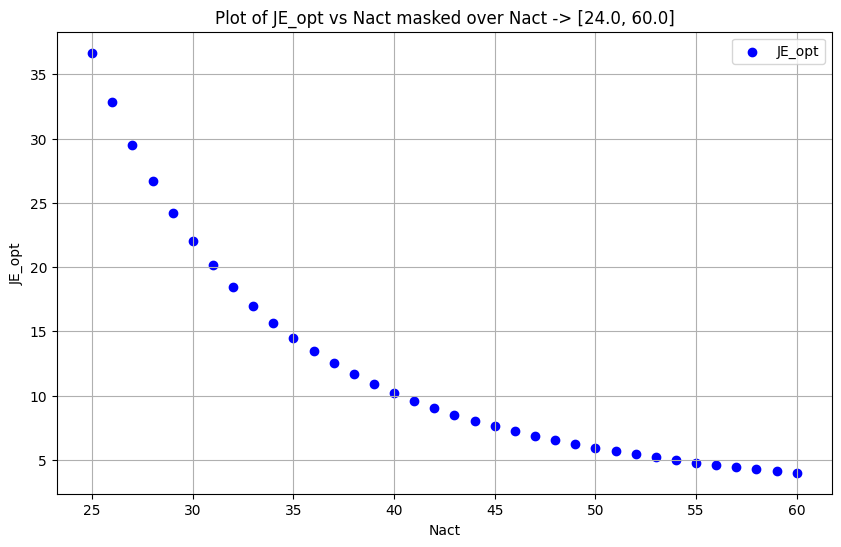

,Nact,JE_opt
0,2.0,87561.505409
1,3.0,21905.386638
2,4.0,8770.567662
3,5.0,4390.698410
4,6.0,2512.757565
5,7.0,1573.275553
6,8.0,1051.010148
7,9.0,737.424470
8,10.0,537.708253
9,11.0,404.444677


We select a JE_opt value of: 4.0 given Nact = 60


In [4]:
def computeOptimalJe(numNeurons = 120):
    Nact = np.linspace(2, numNeurons-2, numNeurons-3)
    n_tilde = Nact - numNeurons/2
    deltaTheta = 2*pi/numNeurons

    JE_inv = 1/4 + (n_tilde+sin(n_tilde*deltaTheta)/sin(deltaTheta))/(2*numNeurons)
    JE_opt = 1/JE_inv
    return JE_opt, JE_inv, Nact

JE_opt, JE_inv, Nact = computeOptimalJe(numNeurons = N)

# Plotting JE_opt
fig = plt.figure(figsize=(10, 6))
mask = (Nact <= N/2) & (Nact > N/5)
plt.scatter(Nact[mask], JE_opt[mask], label='JE_opt', color='blue')
plt.xlabel('Nact')
plt.ylabel('JE_opt')
plt.title(f'Plot of JE_opt vs Nact masked over Nact -> [{N/5}, {N/2}]')
plt.legend()
plt.grid()
plt.show()

JE_df = pd.DataFrame({'Nact': Nact, 'JE_opt': JE_opt})
display(JE_df.head(20))

JE_chosen = JE_df[JE_df['Nact'] == N//2]['JE_opt'].iloc[0]
print("We select a JE_opt value of:", JE_chosen, "given Nact =", N//2)

JE_chosen = 69.51337004749652

In [5]:
# Step 2 Implementation: Basis Functions and Contour Method
# This implementation is independent of any specific network class
from multiprocessing import Pool, cpu_count
import time

def _process_single_point(args):
    """
    Helper function to process a single (psi, w) point for parallelization.
    
    Parameters:
    -----------
    args : tuple
        (psi_val, w_val, theta_j, N) where:
        - psi_val: Bump phase value
        - w_val: Bump width value
        - theta_j: Array of neuron positions
        - N: Number of neurons
    
    Returns:
    --------
    tuple
        (f_0, f_even, f_odd) for this specific point
    """
    psi_val, w_val, theta_j, N = args
    
    # Compute circular distance for each neuron to the bump center
    theta_diff = np.mod(theta_j - psi_val + np.pi, 2*np.pi) - np.pi
    
    # Identify active neurons (those within the bump)
    active_mask = np.abs(theta_diff) <= w_val/2
    
    # Skip if no active neurons
    num_active = np.sum(active_mask)
    if num_active == 0:
        return 0.0, 0.0, 0.0
    
    # Calculate the activity term for active neurons: (cos(θ_k - ψ) - cos(w/2))
    cos_diff = np.cos(theta_j[active_mask] - psi_val) - np.cos(w_val/2)
    
    # f_0: Average of (cos(θ_k - ψ) - cos(w/2)) for active neurons
    f_0 = np.sum(cos_diff) / N
    
    # f_even: Average of (cos(θ_k - ψ) - cos(w/2)) * cos(θ_k - ψ) for active neurons
    cos_terms = cos_diff * np.cos(theta_j[active_mask] - psi_val)
    f_even = np.sum(cos_terms) / N
    
    # f_odd: Average of (cos(θ_k - ψ) - cos(w/2)) * sin(θ_k - ψ) for active neurons
    sin_terms = cos_diff * np.sin(theta_j[active_mask] - psi_val)
    f_odd = np.sum(sin_terms) / N
    
    return f_0, f_even, f_odd

def calculate_basis_functions(psi, w, N, parallel=True, n_workers=None):
    """
    Calculate the basis functions f_0, f_even, and f_odd for the given parameters.
    
    Parameters:
    -----------
    psi : float or array-like
        Bump center position(s) (phase values). Can be a scalar, grid, or flattened array.
    w : float or array-like
        Bump width(s). Must be the same shape as psi if both are arrays.
    N : int
        Number of neurons in the network.
    parallel : bool, optional
        Whether to use parallel processing. Default is True.
    n_workers : int, optional
        Number of worker processes to use. If None, uses number of CPU cores.
        
    Returns:
    --------
    tuple
        (f_0, f_even, f_odd) - Scalar values if inputs are scalar, otherwise arrays of the same shape
    """
    # Convert scalar inputs to arrays if needed
    scalar_input = np.isscalar(psi) and np.isscalar(w)
    if scalar_input:
        psi = np.array([psi])
        w = np.array([w])
    
    # Generate neuron positions (equally spaced around the circle)
    theta_j = np.linspace(0, 2*np.pi, N, endpoint=False)
    
    # Prepare inputs for processing
    original_shape = psi.shape
    psi_flat = psi.flatten()
    w_flat = w.flatten()
    n_points = len(psi_flat)
    # print("Same length?", n_points == len(w_flat))

    # Initialize output arrays
    f_0_flat = np.zeros(n_points)
    f_even_flat = np.zeros(n_points)
    f_odd_flat = np.zeros(n_points)
    
    if parallel and n_points > 100:  # Only use parallel for many points
        # Prepare arguments for parallel processing
        args_list = [(psi_flat[i], w_flat[i], theta_j, N) for i in range(n_points)]
        
        # Determine number of workers
        if n_workers is None:
            n_workers = max(1, cpu_count() - 1)  # Leave one CPU free
        
        # Process in parallel
        with Pool(processes=n_workers) as pool:
            results = pool.map(_process_single_point, args_list)
            
        # Unpack results
        for i, (f0, fe, fo) in enumerate(results):
            f_0_flat[i] = f0
            f_even_flat[i] = fe
            f_odd_flat[i] = fo
    else:
        # Sequential processing
        for i in range(n_points):
            psi_val = psi_flat[i]
            w_val = w_flat[i]
            
            # Compute circular distance for each neuron to the bump center
            theta_diff = np.mod(theta_j - psi_val + np.pi, 2*np.pi) - np.pi
            
            # Identify active neurons (those within the bump)
            active_mask = np.abs(theta_diff) <= w_val/2
            
            # Skip if no active neurons
            num_active = np.sum(active_mask)
            if num_active == 0:
                print("No active neurons at this point")
                continue
            
            # Calculate the activity term for active neurons: (cos(θ_k - ψ) - cos(w/2))
            cos_diff = np.cos(theta_j[active_mask] - psi_val) - np.cos(w_val/2)
            
            # f_0: Average of (cos(θ_k - ψ) - cos(w/2)) for active neurons
            f_0_flat[i] = np.sum(cos_diff) / N
            
            # f_even: Average of (cos(θ_k - ψ) - cos(w/2)) * cos(θ_k - ψ) for active neurons
            cos_terms = cos_diff * np.cos(theta_j[active_mask] - psi_val)
            f_even_flat[i] = np.sum(cos_terms) / N
            
            # f_odd: Average of (cos(θ_k - ψ) - cos(w/2)) * sin(θ_k - ψ) for active neurons
            sin_terms = cos_diff * np.sin(theta_j[active_mask] - psi_val)
            f_odd_flat[i] = np.sum(sin_terms) / N
    
    # Reshape results back to original shape or return scalar
    f_0 = f_0_flat.reshape(original_shape)
    f_even = f_even_flat.reshape(original_shape)
    f_odd = f_odd_flat.reshape(original_shape)
    
    # Return scalar values if inputs were scalars
    if scalar_input:
        f_0 = f_0[0]
        f_even = f_even[0]
        f_odd = f_odd[0]
    
    return f_0, f_even, f_odd



In [6]:
import matplotlib.pyplot as plt
from matplotlib import contour
from scipy.interpolate import interpn

def find_contour_points(N, f_even_grid, psi_grid, w_grid, je_target, f_0_grid=None, f_odd_grid=None,
                        return_type='dataframe', visualize=False, interpolate=False):
    """
    A Pythonic implementation of contour finding similar to MATLAB's contourc.
    Finds points where f_even = 1/je_target.
    
    Parameters:
    -----------
    f_even_grid : ndarray
        2D array containing f_even values at grid points
    psi_grid : ndarray
        2D meshgrid of psi values
    w_grid : ndarray
        2D meshgrid of width values
    je_target : float
        Target Je value to find contour for (will find where f_even = 1/je_target)
    f_0_grid : ndarray, optional
        2D array containing f_0 values at grid points (for interpolation)
    f_odd_grid : ndarray, optional
        2D array containing f_odd values at grid points (for interpolation)
    return_type : str, optional
        'dataframe' for pandas DataFrame, 'arrays' for (psi, width) arrays
    visualize : bool, optional
        Whether to plot the contour
  
    Returns:
    --------
    contour_points : DataFrame or tuple
        Either a DataFrame with psi and width columns, or a tuple of (psi, width) arrays
    """
    # Create a figure for the contour calculation
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    
    # Compute the contour lines at the specific level 1/je_target
    contour_level = 1/je_target
    
    # Draw contour
    contour_set = ax.contour(psi_grid, w_grid, f_even_grid, levels=[contour_level], colors='r', linewidths=2)
    
    # Extract contour data
    all_contour_points = []
    
    # Get all the contour segments
    for i in range(len(contour_set.allsegs)):
        for segment in contour_set.allsegs[i]:
            if len(segment) > 0:
                psi_points = segment[:, 0]
                width_points = segment[:, 1]
                
                # Append to our list of points
                for j in range(len(psi_points)):
                    all_contour_points.append((psi_points[j], width_points[j]))
    
    # If no contour points were found
    if not all_contour_points:
        raise ValueError("No contour points found for the specified je_target.")
        if return_type == 'dataframe':
            return pd.DataFrame(columns=['psi', 'width'])
        else:
            return np.array([]), np.array([])
    
    # Convert to arrays
    contour_points = np.array(all_contour_points)
    psi_contour = contour_points[:, 0]
    width_contour = contour_points[:, 1]
    
    # Interpolate f_0 and f_odd values if grids are provided
    f_0_values = None
    f_odd_values = None
    
    if f_0_grid is not None and f_odd_grid is not None and interpolate:
        try:
            # Extract the 1D coordinates from the meshgrid for interpolation
            psi_1d = psi_grid[0, :]  # First row contains all psi values
            w_1d = w_grid[:, 0]      # First column contains all w values

            # Create interpolation points
            points = (w_1d, psi_1d)
            xi = np.column_stack((width_contour, psi_contour))

            # Interpolate values
            f_0_values = interpn(points, f_0_grid.T, xi, method='linear', bounds_error=False)
            f_odd_values = interpn(points, f_odd_grid.T, xi, method='linear', bounds_error=False)
        except Exception as e:
            print(f"Interpolation error: {e}")
    else:
        f_0_values, _, f_odd_values = calculate_basis_functions(psi_contour, width_contour, N)

    # Visualization with more information and without using colorbar
    if visualize:
        # Add a filled contour plot to show the overall f_even landscape
        cf = ax.contourf(psi_grid, w_grid, f_even_grid, levels=20, alpha=0.5, cmap='viridis')
          
        # Add the specific contour level for Je=target
        ax.contour(psi_grid, w_grid, f_even_grid, levels=[contour_level], 
                  colors='r', linewidths=2, linestyles='solid')
        
        # Add a colorbar for the filled contour
        plt.colorbar(cf, ax=ax, label='f_even')
        
        # Add title and labels
        ax.set_title(f'Contour where f_even = 1/{je_target:.4f}')
        ax.set_xlabel('psi (angle)')
        ax.set_ylabel('width')
        
        # Add a text annotation explaining the red line
        ax.text(0.05, 0.95, f'Red line: f_even = {contour_level:.6f}', 
                transform=ax.transAxes, color='r', fontweight='bold')
        
        plt.show()
    else:
        plt.close(fig)
    
    # Return the result in the requested format
    if return_type == 'dataframe':
        df = pd.DataFrame({
            'psi': psi_contour,
            'width': width_contour
        })
        
        # Add interpolated values if available
        if f_0_values is not None:
            df['f_0'] = f_0_values
            df['f_odd'] = f_odd_values
        
        return df
    else:
        if f_0_values is not None:
            return psi_contour, width_contour, f_0_values, f_odd_values
        else:
            return psi_contour, width_contour

In [7]:
f_0_grid, f_even_grid, f_odd_grid = calculate_basis_functions(psi_grid, w_grid, N)

contour_df = find_contour_points(N, f_even_grid, psi_grid, w_grid, je_target=JE_chosen,
                                 f_0_grid=f_0_grid, f_odd_grid=f_odd_grid,
                                 return_type='dataframe', visualize=False)

display(contour_df)

,psi,width,f_0,f_odd
0,0.000000,1.047117,0.014778,-8.023096e-19
1,0.005236,1.046769,0.014783,-1.130988e-09
2,0.010472,1.046437,0.014784,-4.825957e-10
3,0.015708,1.046199,0.014785,-1.232286e-10
4,0.020721,1.046063,0.014786,4.200792e-10
...,...,...,...,...
1435,6.262241,1.046057,0.014786,2.823081e-12
1436,6.262464,1.046063,0.014786,-4.200792e-10
1437,6.267477,1.046199,0.014785,1.232286e-10
1438,6.272713,1.046437,0.014784,4.825957e-10


In [8]:
def computeJi(psi_contour, width_contour, je_target, f_0_contour, A, cff, N):
    """
    Calculate inhibitory weights (Ji) from contour points for given parameters.
    
    Parameters:
    -----------
    psi_contour : ndarray
        Array of psi values on the contour
    width_contour : ndarray
        Array of width values on the contour
    je_target : float
        Target Je value used for the contour
    f_0_contour : ndarray
        Array of f_0 values on the contour
    A : float
        Target amplitude parameter
    cff : float
        Baseline parameter
    N : int
        Number of neurons
        
    Returns:
    --------
    Ji : float
        Optimal inhibitory connection strength
    """
    # Calculate Ji needed for desired amplitude
    ratio = cff / A
    Ji_values = ((ratio - 1) * np.cos(width_contour/2) - ratio) / f_0_contour

    # Choose minimum value as in original code
    Ji = np.min(Ji_values)
    
    # Check stability bound
    Ji_upper_bound = np.min(-np.cos(width_contour/2) / f_0_contour)
    
    if Ji_upper_bound - Ji <= 0:
        print(f"Warning: Calculated Ji outside of marginally stable regime for Je = {je_target}")

    return Ji, Ji_upper_bound

In [9]:
cff = 1.0
A = 0.2

JI_chosen, JI_UpperBound = computeJi(psi_contour = contour_df['psi'], width_contour = contour_df['width'],
                          je_target = JE_chosen, f_0_contour = contour_df['f_0'],
                          A = A, cff = cff, N = N)

print(JI_chosen, JI_UpperBound)

-103.92710109941913 -58.60432379117715


In [20]:
def freq2current(freq, tau, tau_ref, Vth, Vreset, Vrest):
    T = 1/freq
    k = exp((T-tau_ref)/tau)
    deltaTh = (Vth - Vrest)
    deltaReset = (Vreset - Vrest)

    Iext = (k*deltaTh - deltaReset)/(k-1)
    return Iext



def current2freq(Iext, tau, tau_ref, Vth, Vreset, Vrest):
    """
    Calculate the firing rate (frequency) of a neuron given the external current.

    Parameters:
    -----------
    Iext : float
        External current (in amperes).
    tau : float
        Membrane time constant (in seconds).
    tau_ref : float
        Absolute refractory period (in seconds).
    Vth : float
        Threshold voltage (in volts).
    Vreset : float
        Reset voltage after a spike (in volts).
    Vrest : float
        Resting membrane potential (in volts).

    Returns:
    --------
    float
        Firing rate (frequency) in Hz.
    """
    numerator = Iext + Vreset - Vrest
    denominator = Iext + Vth - Vrest
    if denominator <= 0:
        raise ValueError("Invalid parameters: denominator must be positive.")
    
    T = tau * np.log(numerator / denominator) + tau_ref
    return 1 / T

tau=10e-3
tau_ref=5e-3
Vth=-48e-3
Vreset=-80e-3
Vrest=-70e-3

CFF = freq2current(freq=60, tau=tau, tau_ref=tau_ref, Vth=Vth, Vreset=Vreset, Vrest=Vrest)
print(f"The current Cff for a frequency of 1 Hz is {CFF*amp}")

AFF = freq2current(freq=60, tau=tau, tau_ref=tau_ref, Vth=Vth, Vreset=Vreset, Vrest=Vrest)
print(f"The current Aff for a frequency of 60 Hz is {AFF*amp}")

Iext = freq2current(freq=1, tau=tau, tau_ref=tau_ref, Vth=Vth, Vreset=Vreset, Vrest=Vrest)
print(f"The current Iext for a frequency of 60 Hz is {Iext*amp}")

The current Cff for a frequency of 1 Hz is 36.47131836 mA
The current Aff for a frequency of 60 Hz is 36.47131836 mA
The current Iext for a frequency of 60 Hz is 22. mA


In [11]:
print(f"For N={N}, amplitude A={A}, cff={cff},\n"
      f"for a choice of JE={JE_chosen}, the optimal Ji values are: {JI_chosen}")

For N=120, amplitude A=0.2, cff=1.0,
for a choice of JE=69.51337004749652, the optimal Ji values are: -103.92710109941913


In [12]:
val = current2freq(Iext = 22, tau=tau, tau_ref=tau_ref, Vth=Vth, Vreset=Vreset, Vrest=Vrest)
print(val)

200.58335622377624


In [13]:
raise SystemExit

SystemExit: 

WARNING    /home/bmaacaron-iit.local/.virtualenvs/JointAttractorNets-Brian2/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
 [py.warnings]


In [ ]:
# Calculate basis functions over the grid directly
f_0_grid, f_even_grid, f_odd_grid = calculate_basis_functions(psi_grid, w_grid, N)

In [ ]:
# Choose the values for which fodd = 0
mask = f_odd_grid == 0
print(np.sum(mask), "points found where f_odd = 0")

In [ ]:
f_even_opt = f_even_grid[mask]

# Find all JE > 2 such that JE = 1/f_even_grid
# JE_grid = 1 / f_even_opt
JE_grid = 1 / f_even_grid
JE_mask = JE_grid > 2

JE_values = JE_grid[JE_mask]
print("Number of JE values found: ", JE_values.size)
print("The range of JE values is from ", JE_values.min(), " to ", JE_values.max())

JE_unique = np.unique(JE_values)
print("There are ", JE_unique.size, " unique JE values.")
print("The set of unique JE values is: ", JE_unique)

In [ ]:
# Extract corresponding psi and w values for each JE value
# psi_values = psi_grid[mask][JE_mask]  # First apply f_odd=0 mask, then JE>2 mask
# w_values = w_grid[mask][JE_mask]      # Same as above

psi_values = psi_grid[JE_mask]  # First apply f_odd=0 mask, then JE>2 mask
w_values = w_grid[JE_mask]      # Same as above

# Create a DataFrame to organize and display the results
import pandas as pd
results_df = pd.DataFrame({
    'psi': psi_values,
    'width': w_values,
    'JE': JE_values,
    # 'f_even': f_even_opt[JE_mask]
    'f_even': f_even_grid[JE_mask]
})

# Sort by JE value for clearer viewing
results_df = results_df.sort_values(by='JE')

print(f"Found {len(results_df)} points with f_odd=0 and JE>2")
print("\nSample of corresponding values (first 10 rows):")
display(results_df.head(5))


In [ ]:
JE_ = results_df['JE'].min()
print(f"Minimum JE value: {JE_}")

JE_max = results_df['JE'].max()
print(f"Maximum JE value: {JE_max}")

# Calculate J_I^bound based on the equation: J_I^bound = min_(w,ψ)∈C_L [-cos(w/2) / f_0(w,ψ)]
# Where C_L is the set of points where f_even(w,ψ) = 1/JE

# Use the existing f_0 values from our previous calculation
# Extract f_0 values corresponding to our masked points
# f0_values = f_0_grid[mask][JE_mask]
f0_values = f_0_grid[JE_mask]


# Add f_0 to our DataFrame
results_df['f_0'] = f0_values

# Calculate the term inside J_I^bound for each point: -cos(w/2) / f_0(w,ψ)
results_df['ji_bound'] = -np.cos(results_df['width'] / 2) / results_df['f_0']

# Find J_I^bound (minimum value of the term)
ji_bound = results_df['ji_bound'].min()
ji_idx = results_df['ji_bound'].idxmin()

# Print results
print("\nJ_I^bound Calculation Results:")
print(f"J_I^bound = {ji_bound:.4f}")
print("\nParameters at minimum point:")
print(f"psi = {results_df['psi'].iloc[ji_idx]:.4f}")
print(f"w = {results_df['width'].iloc[ji_idx]:.4f}")
print(f"JE = {results_df['JE'].iloc[ji_idx]:.4f}")
print(f"f_0 = {results_df['f_0'].iloc[ji_idx]:.4f}")
print(f"f_even = {results_df['f_even'].iloc[ji_idx]:.4f}")

Regarding cff here, in theory it should be the value that sets the neuron to a sub threshold level. 
I assumed it would be $cff = 23 mV$. However, it seems like if the math is correct that $cff = V_{rest} + I_{ff}$ and that we were in fact taking $I_{ff}$ as 23 mv and not $cff$.
Additionally, their model assumes 0 as being the baseline of non-activity.
In our case, the neuron is not active below a threshold $V_{th} = -48 mV.$

As such I wonder if instead I should set: $$cff = V_{rest} + I_{ff} - V_{th}$$

In [ ]:
Vth = -48
V_rest = -70
I_ff = 23

print("All three possible values of cff")
print("cff = 23 mV")
print(f"cff = V_rest + I_ff = {V_rest + I_ff} mV")
print(f"cff = V_rest + I_ff - V_th = {V_rest + I_ff - Vth} mV")
# print(V_rest-Vth*1e3)

cff = 1.0
A = 0.2

results_df['ji_range'] = ((cff/(A-1))*(np.cos(results_df['width'] / 2)) - (cff/A)) / results_df['f_0']
ji_opt = results_df['ji_range'].min()

print("ji_opt Calculation Results:", ji_opt)
print("Is ji_opt < ji_bound?", ji_opt < ji_bound)